In [9]:

# up Flower Classification with ResNet18 and Enhanced Visualizations

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import torchvision

# ==== CONFIGURATION ====
data_dir = r"D:\ml_lern\dataset"
batch_size = 16
image_size = 128
epochs = 3
learning_rate = 0.0001
model_save_path = "models/flower_resnet18.pth"

# ==== DEVICE SETUP ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==== DATA TRANSFORMS ====
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ==== LOAD DATASET AND SPLIT ====
dataset = datasets.ImageFolder(root=data_dir, transform=transform_train)
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])
val_set.dataset.transform = transform_val
test_set.dataset.transform = transform_val

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

class_names = dataset.classes
num_classes = len(class_names)
print(f"Classes found: {class_names}")
print(f"Total images: {total_size}")

# ==== MODEL SETUP ====
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ==== LOSS AND OPTIMIZER ====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ==== TRAINING LOOP ====
train_losses = []
train_accuracies = []
val_accuracies = []
epoch_times = []

print("Starting training...\n")
for epoch in range(epochs):
    model.train()
    start_time = time.time()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            val_outputs = model(val_images)
            _, val_preds = torch.max(val_outputs, 1)
            val_correct += (val_preds == val_labels).sum().item()
            val_total += val_labels.size(0)

    val_acc = 100 * val_correct / val_total

    end_time = time.time()
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    val_accuracies.append(val_acc)
    epoch_times.append(end_time - start_time)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.2f}% - Val Acc: {val_acc:.2f}%")

print("\nTraining complete!")

# ==== SAVE MODEL ====
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")


Using device: cpu
Classes found: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total images: 4317
Starting training...

Epoch [1/3] - Loss: 0.5681 - Acc: 79.54% - Val Acc: 86.86%
Epoch [2/3] - Loss: 0.1627 - Acc: 94.47% - Val Acc: 89.34%
Epoch [3/3] - Loss: 0.0822 - Acc: 97.58% - Val Acc: 88.41%

Training complete!
Model saved to models/flower_resnet18.pth


In [6]:
import torch
import torchvision
import torchaudio

print("PyTorch version:", torch.__version__)


PyTorch version: 2.7.1+cpu


In [5]:
import sys
print(sys.executable)


d:\ml_lern\.venv\Scripts\python.exe


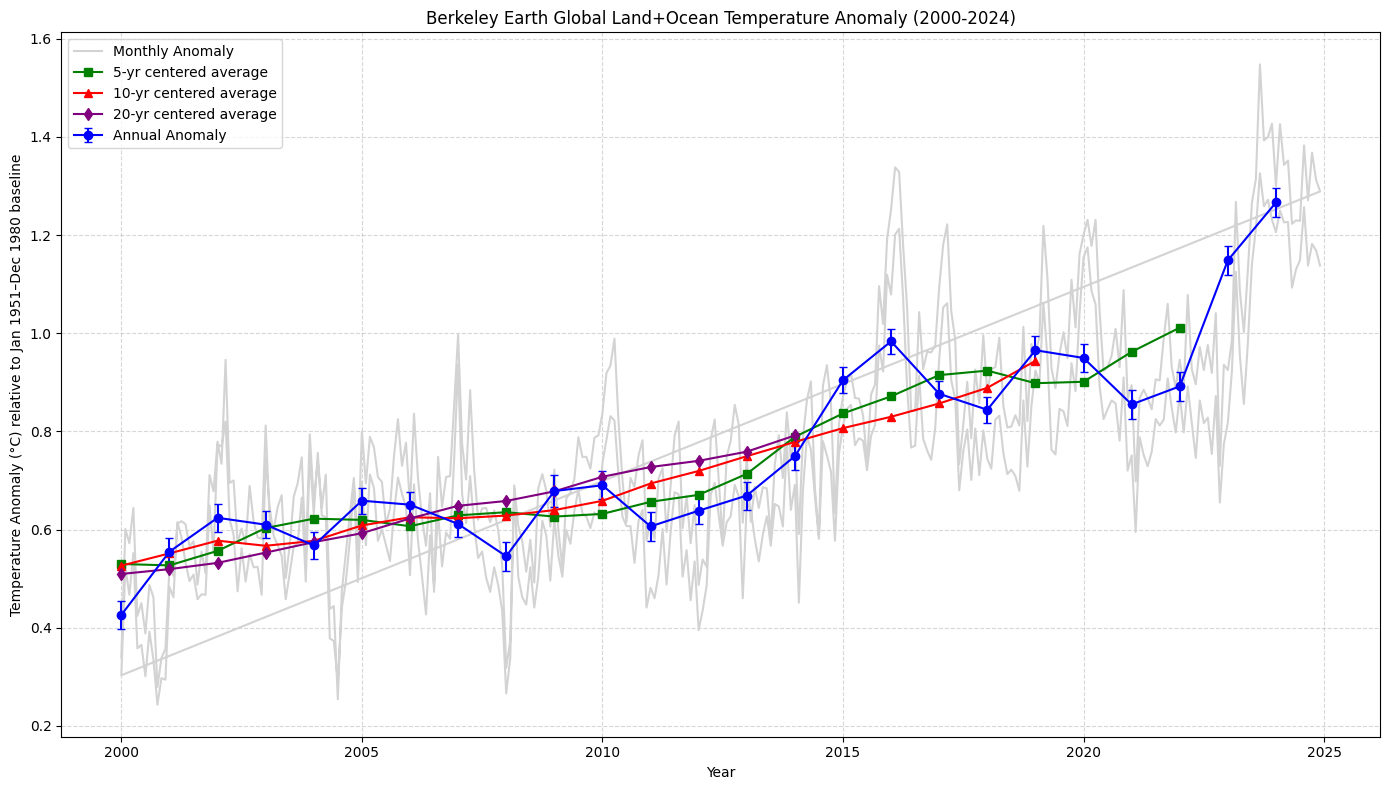

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import requests

# ----- Step 1: Download Data -----
url = "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_complete.txt"
resp = requests.get(url)
resp.raise_for_status()
text = resp.text

# ----- Step 2: Parse Data -----
# skip commented lines
lines = [l for l in text.splitlines() if not l.startswith('%') and l.strip() != ""]
# the header line we want is the first after comments
# We know columns: Year, Month, Anomaly, Unc., Annual Anomaly, Annual Unc., Five-year, Five-year unc, Ten-yr, Ten-yr unc, Twenty-yr, Twenty-yr unc
header = ["Year","Month",
          "Monthly_Anomaly","Monthly_Uncertainty",
          "Annual_Anomaly","Annual_Uncertainty",
          "FiveYr_Anomaly","FiveYr_Uncertainty",
          "TenYr_Anomaly","TenYr_Uncertainty",
          "TwentyYr_Anomaly","TwentyYr_Uncertainty"]
data = []
for ln in lines:
    parts = ln.split()
    if len(parts) >= 12:
        # take first 12 fields
        try:
            row = [int(parts[0]), int(parts[1])] + [float(parts[i]) for i in range(2,12)]
            data.append(row)
        except ValueError:
            # skip malformed line
            continue

df = pd.DataFrame(data, columns=header)

# ----- Step 3: Filter for 2000-2024 -----
df2 = df[(df["Year"] >= 2000) & (df["Year"] <= 2024)]

# ----- Step 4: Plotting -----
plt.figure(figsize=(14,8))

# Monthly anomaly
plt.plot(df2["Year"] + (df2["Month"]-1)/12.0, df2["Monthly_Anomaly"], color='lightgrey', label="Monthly Anomaly")

# Annual average
# We need to compute or use the "Annual_Anomaly" values reported (which appear in data per month but duplicate per month for same year)
annual = df2.groupby("Year").agg({
    "Annual_Anomaly":"mean",
    "Annual_Uncertainty":"mean"
}).reset_index()
plt.errorbar(annual["Year"], annual["Annual_Anomaly"], yerr=annual["Annual_Uncertainty"],
             fmt='-o', capsize=3, label="Annual Anomaly", color='blue')

# 5-year moving average
# The dataset already gives a 5-yr centered average per month; we can sample yearly by taking the record for, say, June (month=6) each year
# But simpler: group by Year, take mean of the FiveYr_Anomaly
five = df2.groupby("Year").agg({"FiveYr_Anomaly":"mean"}).reset_index()
plt.plot(five["Year"], five["FiveYr_Anomaly"], '-s', label="5-yr centered average", color='green')

# 10-yr moving average
ten = df2.groupby("Year").agg({"TenYr_Anomaly":"mean"}).reset_index()
plt.plot(ten["Year"], ten["TenYr_Anomaly"], '-^', label="10-yr centered average", color='red')

# 20-yr moving average
twenty = df2.groupby("Year").agg({"TwentyYr_Anomaly":"mean"}).reset_index()
plt.plot(twenty["Year"], twenty["TwentyYr_Anomaly"], '-d', label="20-yr centered average", color='purple')

# Formatting
plt.title("Berkeley Earth Global Land+Ocean Temperature Anomaly (2000-2024)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C) relative to Jan 1951–Dec 1980 baseline")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


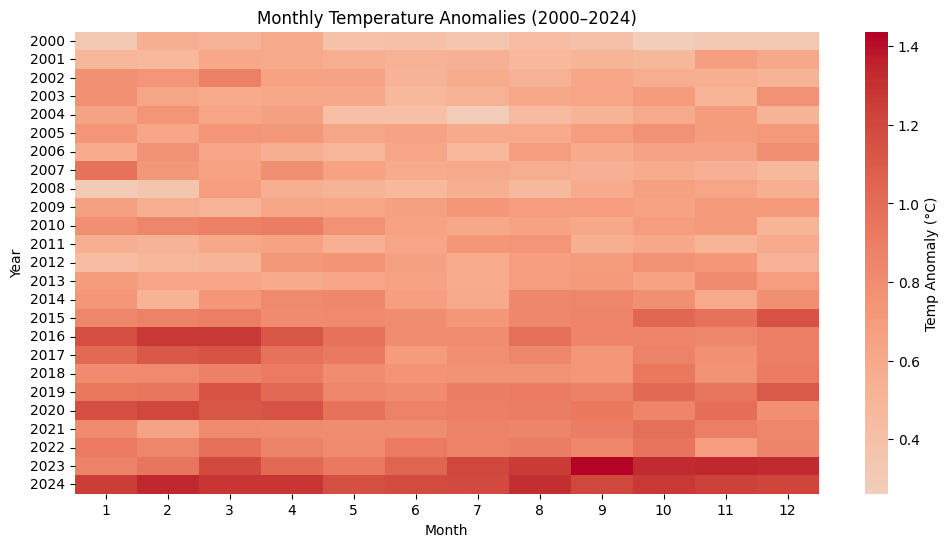

In [5]:
import seaborn as sns

# Pivot table for heatmap
pivot = df2.pivot_table(values="Monthly_Anomaly", index="Year", columns="Month")

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="coolwarm", center=0, annot=False, cbar_kws={'label': 'Temp Anomaly (°C)'})
plt.title("Monthly Temperature Anomalies (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_26276\4287031984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Year", y="Monthly_Anomaly", data=df2, palette="coolwarm")


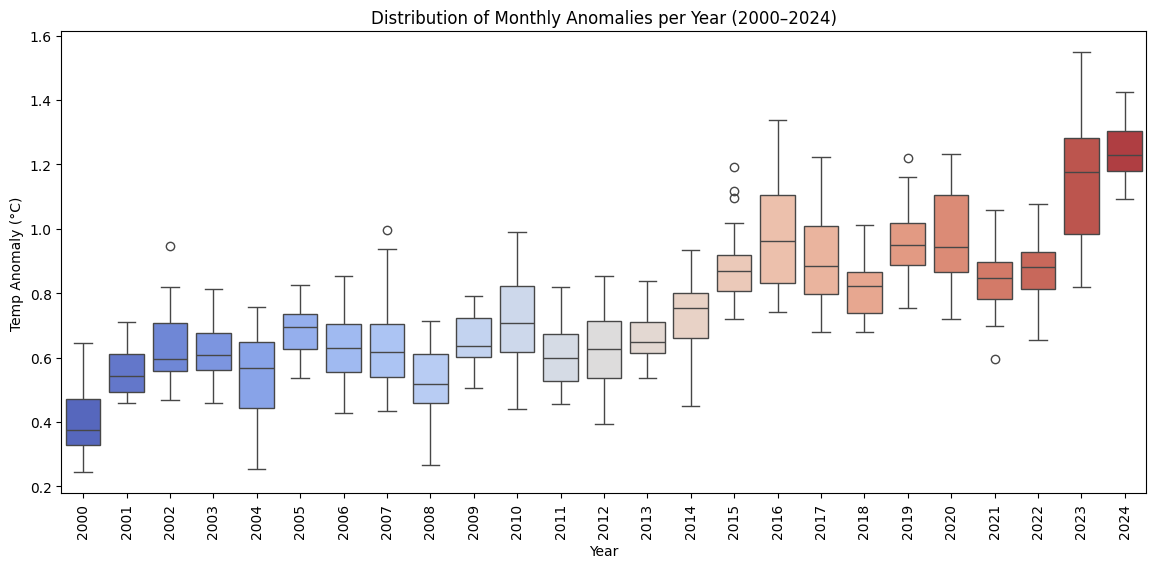

In [6]:
plt.figure(figsize=(14,6))
sns.boxplot(x="Year", y="Monthly_Anomaly", data=df2, palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Distribution of Monthly Anomalies per Year (2000–2024)")
plt.ylabel("Temp Anomaly (°C)")
plt.show()


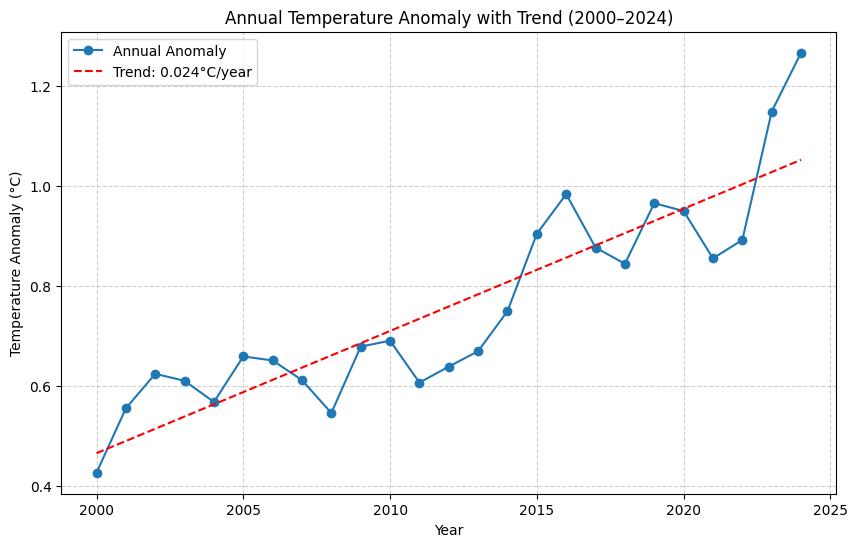

In [7]:
import numpy as np

X = annual["Year"]
y = annual["Annual_Anomaly"]
coef = np.polyfit(X, y, 1)  # linear regression
trend = np.polyval(coef, X)

plt.figure(figsize=(10,6))
plt.plot(X, y, 'o-', label="Annual Anomaly")
plt.plot(X, trend, 'r--', label=f"Trend: {coef[0]:.3f}°C/year")
plt.title("Annual Temperature Anomaly with Trend (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


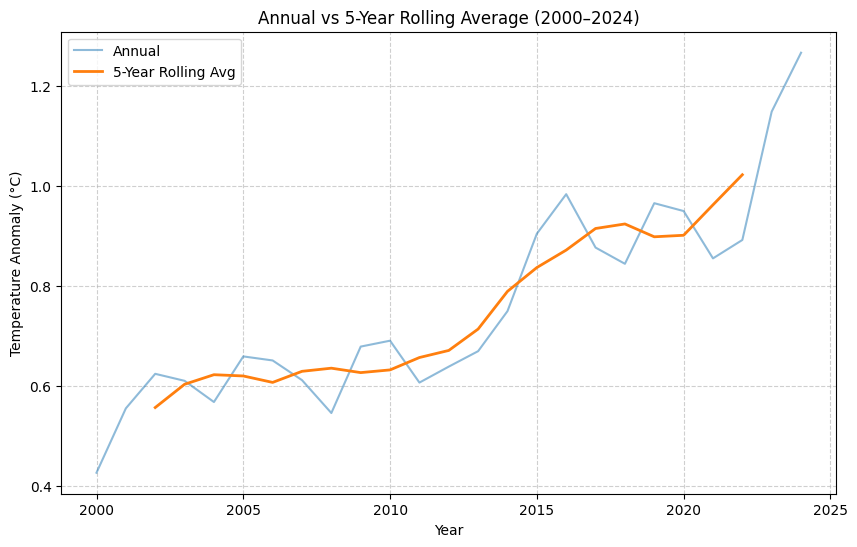

In [8]:
annual["Rolling_5yr"] = annual["Annual_Anomaly"].rolling(5, center=True).mean()

plt.figure(figsize=(10,6))
plt.plot(annual["Year"], annual["Annual_Anomaly"], label="Annual", alpha=0.5)
plt.plot(annual["Year"], annual["Rolling_5yr"], label="5-Year Rolling Avg", linewidth=2)
plt.title("Annual vs 5-Year Rolling Average (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [18]:
import pandas as pd

url = "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_complete.txt"

data = []
with pd.io.common.urlopen(url) as f:
    for line in f:
        line = line.decode("utf-8").strip()
        if line.startswith("#") or line == "":
            continue
        parts = line.split()
        # Check if first two columns are numbers (year and month)
        if parts[0].isdigit() and parts[1].isdigit():
            try:
                year = int(parts[0])
                month = int(parts[1])
                anomaly = float(parts[2])
                data.append([year, month, anomaly])
            except ValueError:
                # Skip malformed lines
                continue

df = pd.DataFrame(data, columns=["Year", "Month", "Monthly_Anomaly"])

# Aggregate annual anomaly
annual = df.groupby("Year")["Monthly_Anomaly"].mean().reset_index()

# Filter 2000-2024
annual_recent = annual[(annual["Year"] >= 2000) & (annual["Year"] <= 2024)]

print(annual_recent)



     Year  Monthly_Anomaly
150  2000         0.407167
151  2001         0.551125
152  2002         0.634875
153  2003         0.623542
154  2004         0.549708
155  2005         0.682917
156  2006         0.626875
157  2007         0.642458
158  2008         0.529250
159  2009         0.656625
160  2010         0.719708
161  2011         0.606250
162  2012         0.632958
163  2013         0.665833
164  2014         0.731042
165  2015         0.886167
166  2016         0.987542
167  2017         0.901500
168  2018         0.825000
169  2019         0.958167
170  2020         0.989917
171  2021         0.838542
172  2022         0.871917
173  2023         1.160125
174  2024         1.245500


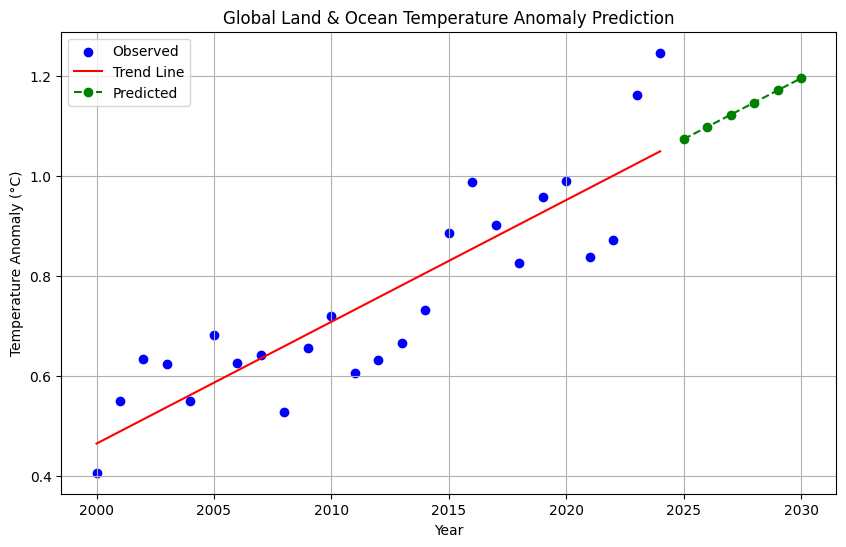

Predicted anomaly for 2025: 1.073 °C
Predicted anomaly for 2026: 1.097 °C
Predicted anomaly for 2027: 1.122 °C
Predicted anomaly for 2028: 1.146 °C
Predicted anomaly for 2029: 1.170 °C
Predicted anomaly for 2030: 1.195 °C


In [19]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Load & preprocess data ---
url = "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_complete.txt"

data = []
with pd.io.common.urlopen(url) as f:
    for line in f:
        line = line.decode("utf-8").strip()
        if line.startswith("#") or line == "":
            continue
        parts = line.split()
        if parts[0].isdigit() and parts[1].isdigit():
            try:
                year = int(parts[0])
                month = int(parts[1])
                anomaly = float(parts[2])
                data.append([year, month, anomaly])
            except ValueError:
                continue

df = pd.DataFrame(data, columns=["Year", "Month", "Monthly_Anomaly"])
annual = df.groupby("Year")["Monthly_Anomaly"].mean().reset_index()
annual_recent = annual[(annual["Year"] >= 2000) & (annual["Year"] <= 2024)]

# --- Step 2: Prepare features & target ---
X = annual_recent["Year"].values.reshape(-1, 1)
y = annual_recent["Monthly_Anomaly"].values

# --- Step 3: Train Linear Regression model ---
model = LinearRegression()
model.fit(X, y)

# --- Step 4: Predict future anomalies (2025-2030) ---
future_years = np.arange(2025, 2031).reshape(-1, 1)
predictions = model.predict(future_years)

# --- Step 5: Visualization ---
plt.figure(figsize=(10,6))
plt.scatter(annual_recent["Year"], annual_recent["Monthly_Anomaly"], color="blue", label="Observed")
plt.plot(annual_recent["Year"], model.predict(X), color="red", label="Trend Line")
plt.plot(future_years, predictions, color="green", linestyle="--", marker='o', label="Predicted")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Global Land & Ocean Temperature Anomaly Prediction")
plt.legend()
plt.grid(True)
plt.show()

# --- Step 6: Print predicted values ---
for year, temp in zip(future_years.flatten(), predictions):
    print(f"Predicted anomaly for {year}: {temp:.3f} °C")


Epoch 10/50, Loss: 0.064276
Epoch 20/50, Loss: 0.033402
Epoch 30/50, Loss: 0.028266
Epoch 40/50, Loss: 0.021956
Epoch 50/50, Loss: 0.019807


C:\Users\User\AppData\Local\Temp\ipykernel_26276\464421962.py:100: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(df_ts.index[-1] + pd.DateOffset(months=1), periods=12, freq='M')


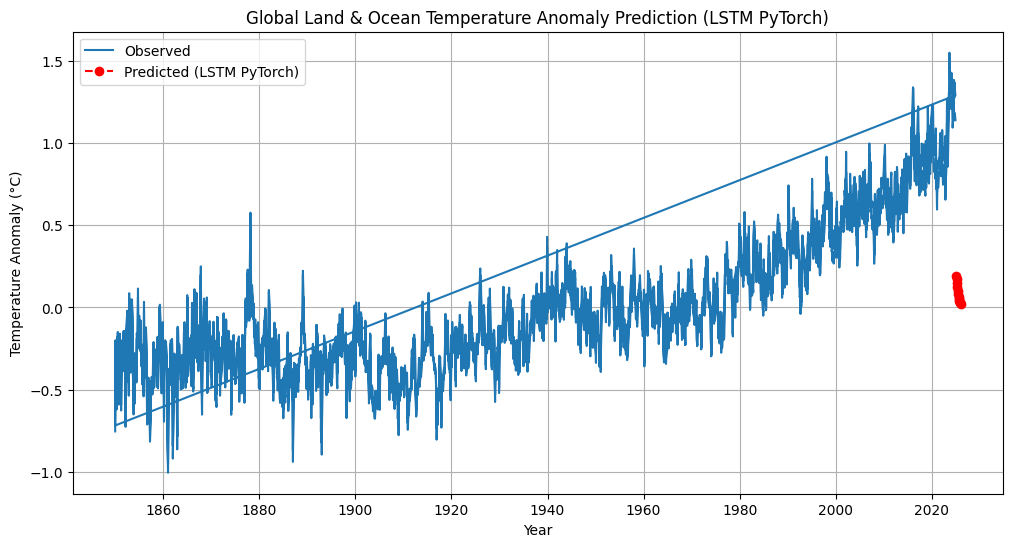

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# --- Step 1: Load & preprocess data ---
url = "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_complete.txt"

data = []
with pd.io.common.urlopen(url) as f:
    for line in f:
        line = line.decode("utf-8").strip()
        if line.startswith("#") or line == "":
            continue
        parts = line.split()
        if parts[0].isdigit() and parts[1].isdigit():
            try:
                year = int(parts[0])
                month = int(parts[1])
                anomaly = float(parts[2])
                data.append([year, month, anomaly])
            except ValueError:
                continue

df = pd.DataFrame(data, columns=["Year", "Month", "Monthly_Anomaly"])
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str))
df_ts = df.set_index("Date")[["Monthly_Anomaly"]]

# --- Step 2: Scale data ---
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df_ts)

# --- Step 3: Create sequences for LSTM ---
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 12
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Convert to PyTorch tensors
X_torch = torch.from_numpy(X).float()
y_torch = torch.from_numpy(y).float()

X_torch = X_torch.view(X_torch.shape[0], SEQ_LENGTH, 1)
y_torch = y_torch.view(y_torch.shape[0], 1)

# --- Step 4: Define LSTM model ---
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1, num_layers=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Step 5: Train model ---
EPOCHS = 50
for epoch in range(EPOCHS):
    model.train()
    outputs = model(X_torch)
    optimizer.zero_grad()
    loss = criterion(outputs, y_torch)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}')

# --- Step 6: Predict future 12 months ---
model.eval()
future_preds = []
future_input = torch.from_numpy(scaled_data[-SEQ_LENGTH:]).float().view(1, SEQ_LENGTH, 1)

for _ in range(12):
    pred = model(future_input)
    future_preds.append(pred.item())
    future_input = torch.cat((future_input[:,1:,:], pred.view(1,1,1)), dim=1)

future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))

# --- Step 7: Visualization ---
plt.figure(figsize=(12,6))
plt.plot(df_ts.index, df_ts["Monthly_Anomaly"], label="Observed")
future_dates = pd.date_range(df_ts.index[-1] + pd.DateOffset(months=1), periods=12, freq='M')
plt.plot(future_dates, future_preds, 'r--', marker='o', label="Predicted (LSTM PyTorch)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Global Land & Ocean Temperature Anomaly Prediction (LSTM PyTorch)")
plt.legend()
plt.grid(True)
plt.show()


Epoch 10/50, Loss: 0.042751
Epoch 20/50, Loss: 0.030429
Epoch 30/50, Loss: 0.025075
Epoch 40/50, Loss: 0.021917
Epoch 50/50, Loss: 0.020022


C:\Users\User\AppData\Local\Temp\ipykernel_26276\1986074376.py:96: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(df_ts.index[-1] + pd.DateOffset(months=1), periods=12, freq='M')


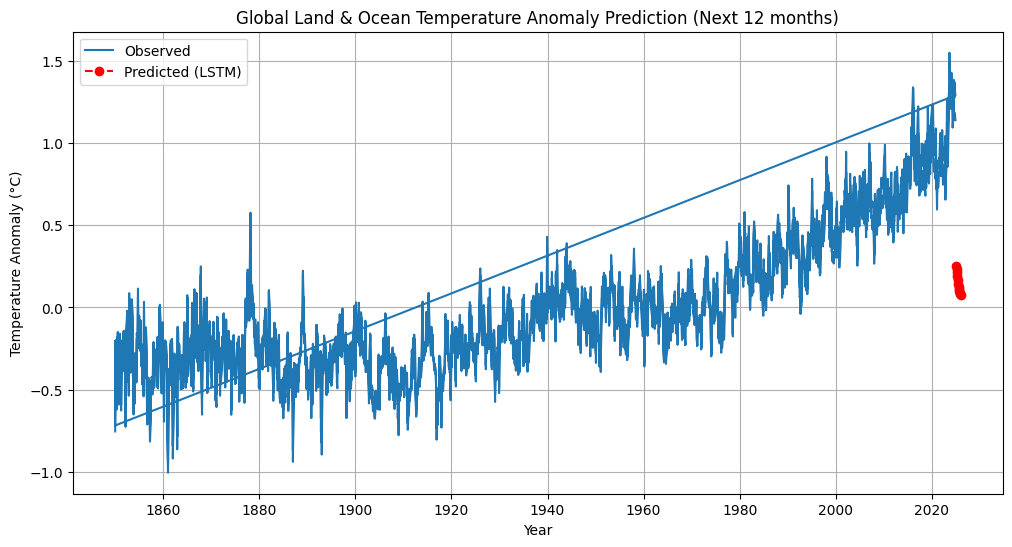

         Date  Predicted_Anomaly
0  2025-01-31           0.253170
1  2025-02-28           0.236009
2  2025-03-31           0.212908
3  2025-04-30           0.188481
4  2025-05-31           0.165268
5  2025-06-30           0.144833
6  2025-07-31           0.127185
7  2025-08-31           0.112413
8  2025-09-30           0.100142
9  2025-10-31           0.090555
10 2025-11-30           0.082887
11 2025-12-31           0.076954


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# --- Step 1: Load & preprocess data ---
url = "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_complete.txt"

data = []
with pd.io.common.urlopen(url) as f:
    for line in f:
        line = line.decode("utf-8").strip()
        if line.startswith("#") or line == "":
            continue
        parts = line.split()
        if parts[0].isdigit() and parts[1].isdigit():
            try:
                year = int(parts[0])
                month = int(parts[1])
                anomaly = float(parts[2])
                data.append([year, month, anomaly])
            except ValueError:
                continue

df = pd.DataFrame(data, columns=["Year", "Month", "Monthly_Anomaly"])
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str))
df_ts = df.set_index("Date")[["Monthly_Anomaly"]]

# --- Step 2: Scale data ---
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df_ts)

# --- Step 3: Create sequences for LSTM ---
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 12
X, y = create_sequences(scaled_data, SEQ_LENGTH)

X_torch = torch.from_numpy(X).float().view(X.shape[0], SEQ_LENGTH, 1)
y_torch = torch.from_numpy(y).float().view(y.shape[0], 1)

# --- Step 4: Define LSTM model ---
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1, num_layers=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Step 5: Train model ---
EPOCHS = 50
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_torch)
    loss = criterion(outputs, y_torch)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}')

# --- Step 6: Predict next 12 months ---
model.eval()
future_preds = []
future_input = torch.from_numpy(scaled_data[-SEQ_LENGTH:]).float().view(1, SEQ_LENGTH, 1)

for _ in range(12):
    pred = model(future_input)
    future_preds.append(pred.item())
    future_input = torch.cat((future_input[:,1:,:], pred.view(1,1,1)), dim=1)

future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))

# --- Step 7: Visualization ---
plt.figure(figsize=(12,6))
plt.plot(df_ts.index, df_ts["Monthly_Anomaly"], label="Observed")
future_dates = pd.date_range(df_ts.index[-1] + pd.DateOffset(months=1), periods=12, freq='M')
plt.plot(future_dates, future_preds, 'r--', marker='o', label="Predicted (LSTM)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Global Land & Ocean Temperature Anomaly Prediction (Next 12 months)")
plt.legend()
plt.grid(True)
plt.show()

# --- Step 8: Print predictions ---
pred_df = pd.DataFrame({"Date": future_dates, "Predicted_Anomaly": future_preds.flatten()})
print(pred_df)
